In [17]:
import numpy as np
x =np.array([[1,2,34],[2,3,4]])
print(x)
print(x.ndim)
print(x.shape)



[[ 1  2 34]
 [ 2  3  4]]
2
(2, 3)


# slicing

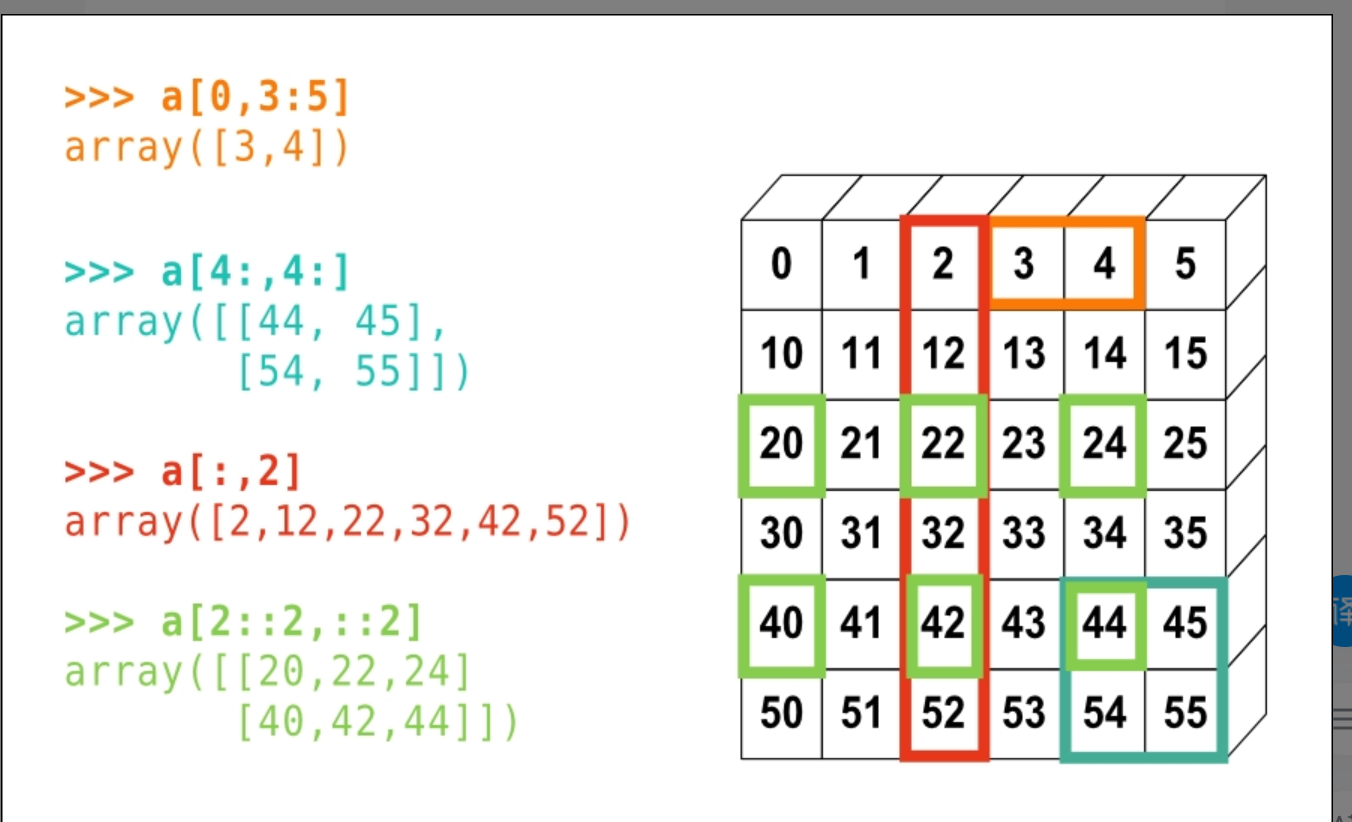

# c-like array: store row first

In [20]:
x = np.random.random((100,100))
y = x[42,87]
print(y)
print(x[2,::5])
print(x.flags)

0.8149813201686744
[0.39320182 0.49795299 0.2301333  0.95693931 0.73693933 0.04711381
 0.64205729 0.80097169 0.38281375 0.4121203  0.6154181  0.61566056
 0.06005893 0.34543291 0.21669763 0.02443639 0.09429653 0.06054521
 0.95019754 0.13234067]
  C_CONTIGUOUS : True
  F_CONTIGUOUS : False
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False



In [21]:
c_array = np.random.rand(10000,10000)
f_array = np.asfortranarray(c_array)
print(c_array.flags)
print(f_array.flags)

def sum_row(x):
    return np.sum(x[0,:])

def sum_column(x):
    return np.sum(x[:,0])

%timeit sum_row(c_array)
%timeit sum_row(f_array)
%timeit sum_column(c_array)
%timeit sum_column(f_array)

  C_CONTIGUOUS : True
  F_CONTIGUOUS : False
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

  C_CONTIGUOUS : False
  F_CONTIGUOUS : True
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

5.8 μs ± 132 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
90 μs ± 3.28 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
89.8 μs ± 1.33 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
5.96 μs ± 252 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# copy and view

In [ ]:
x = np.random.rand(100,10)
y = x[:5,:]
np.may_share_memory(x,y)


# x, y share the same memory so changing y will also change x
y[:] = 0
print(x[:5,:])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [27]:
x = np.random.rand(100,10)

y = np.empty([5,10])
y[:] = x[:5,:]

print(np.may_share_memory(x,y))

y[:] = 0
print(x[:5,:]) # change y will not affect x

False
[[0.95851012 0.53177527 0.61047853 0.44082966 0.63456194 0.07590664
  0.13848249 0.96431954 0.34262329 0.04297197]
 [0.25369577 0.3630025  0.42974309 0.66889112 0.25593059 0.61589994
  0.46078927 0.90283785 0.31412483 0.73038977]
 [0.55760324 0.84918965 0.28585834 0.11596314 0.20764092 0.06137828
  0.54461026 0.12733077 0.87656961 0.69116908]
 [0.55339583 0.18095421 0.07386497 0.35232517 0.89373038 0.19263305
  0.3059894  0.39167153 0.39540776 0.55012562]
 [0.27160159 0.23600582 0.7712381  0.64352002 0.26796587 0.37498206
  0.91384115 0.52982355 0.69176151 0.31726902]]


# create a ndarray

In [28]:
shape_tuple = (2,3,4)
y = np.random.random(shape_tuple)
print(y.shape)
np.random.random?

(2, 3, 4)


Signature: np.random.random(size=None)
Docstring:
random(size=None)

Return random floats in the half-open interval [0.0, 1.0). Alias for
`random_sample` to ease forward-porting to the new random API.
Type:      method

In [29]:
low, high = 1, 11
size = 10
x = np.random.randint(low, high, size = size)
print(x)

[ 3 10  8  5  4  1  1  5  4  4]


# data type

In [30]:
x = np.random.random((10,10))
x.dtype

dtype('float64')

In [31]:
x = np.array(range(10))
x.dtype

dtype('int64')

In [35]:
x = np.array(['hello','world'])
print(x.dtype)
print(''.join(x))
x[0] = 'abcdefgh'
print(x) # the string is truncated to 5 characters

<U5
helloworld
['abcde' 'world']
